## Leaf Disease Classification



*   All done using AI coding, defualt version in Google Colab, Gemini flash 2.5
*   Data Source:https://huggingface.co/datasets/Lindll/maize-leaf-disease?library=datasets



In [ ]:
# Copyright (c) 2026 Victor Jimmy
# All rights reserved.
#
# This code and model may not be copied, modified, distributed, or used
# without explicit written permission from the copyright holder.


In [ ]:
from datasets import load_dataset

ds = load_dataset("Lindll/maize-leaf-disease")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/617 [00:00<?, ?B/s]

data/train-00000-of-00001-3b1e0906129238(…):   0%|          | 0.00/124M [00:00<?, ?B/s]

data/test-00000-of-00001-b481d86c0eb1075(…):   0%|          | 0.00/45.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3350 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/838 [00:00<?, ? examples/s]

In [ ]:
type(ds)

datasets.dataset_dict.DatasetDict

In [ ]:
# Gemini 2.5 flash
# prompt: display the top 5 row of the ds
import pandas as pd

pd.DataFrame(ds['train'][:5])

,image,label
0,<PIL.JpegImagePlugin.JpegImageFile image mode=...,3
1,<PIL.JpegImagePlugin.JpegImageFile image mode=...,1
2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,1
3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,1
4,<PIL.JpegImagePlugin.JpegImageFile image mode=...,0


In [ ]:
# prompt: convert ds to pandas dataframe name it leaf_pd
leaf_pd = ds['train'].to_pandas()

In [ ]:
leaf_pd.head(3)

,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1


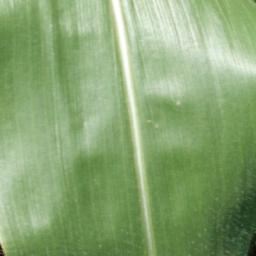

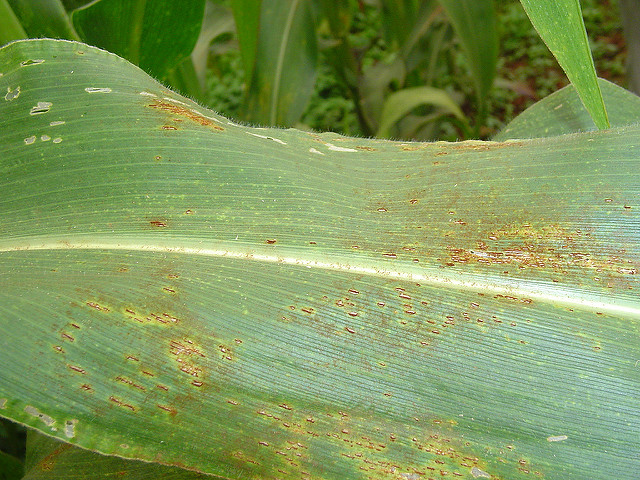

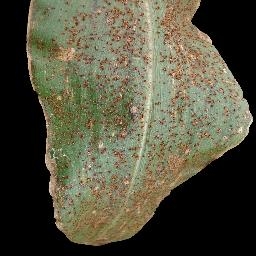

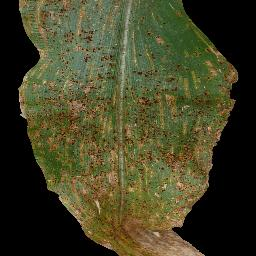

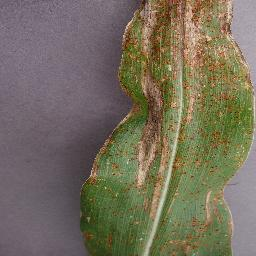

In [ ]:
# prompt: display the first five image in the leaf_pd image column
from IPython.display import display

for i in range(5):
  display(ds['train'][i]['image'])

In [ ]:
leaf_pd.tail(3)

,image,label
3347,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3
3348,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1
3349,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


In [ ]:
# prompt: from Lindll/maize-leaf-disease and leaf_pd column label, how to convert the value to type of disease

# Get the label mapping from the dataset's features
label_names = ds['train'].features['label'].names

# Create a dictionary for mapping numerical labels to disease names
label_to_disease = {i: name for i, name in enumerate(label_names)}

# Map the numerical 'label' column to disease names in leaf_pd
leaf_pd['disease_type'] = leaf_pd['label'].map(label_to_disease)

# Display the updated Dataframe with the new 'disease_type' column
display(leaf_pd.head())

,image,label,disease_type
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3,Healthy
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1,Common_Rust
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1,Common_Rust
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1,Common_Rust
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0,Blight


In [ ]:
leaf_pd.tail(3)

,image,label,disease_type
3347,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3,Healthy
3348,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1,Common_Rust
3349,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0,Blight


In [ ]:
# prompt: show all unique disease_type
unique_disease_types = leaf_pd['disease_type'].unique()

print(unique_disease_types)

['Healthy' 'Common_Rust' 'Blight' 'Gray_Leaf_Spot']


In [ ]:
# prompt: drop the label column in leaf_pd
leaf_pd.drop(columns=['label'], inplace=True)
display(leaf_pd.head())

,image,disease_type
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Healthy
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Common_Rust
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Common_Rust
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Common_Rust
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Blight


In [ ]:
# prompt: (it is an error so I say) fix this error
# Extract actual PIL Image objects from ds['train'] and add them to leaf_pd
# This is necessary because leaf_pd['image'] currently holds dictionaries, not PIL Image objects directly.
leaf_pd['pil_image_data'] = [item['image'] for item in ds['train']]

In [ ]:
# Explicitly convert all images in 'pil_image_data' to RGB to ensure consistent channel numbers

leaf_pd['pil_image_data'] = leaf_pd['pil_image_data'].apply(lambda img: img.convert('RGB') if img.mode != 'RGB' else img)

In [ ]:
# Verify all images are now RGB

non_rgb_modes = leaf_pd['pil_image_data'].apply(lambda img: img.mode if img.mode != 'RGB' else None).dropna().unique()



if len(non_rgb_modes) > 0:

    print(f"Found non-RGB image modes after conversion: {non_rgb_modes}")

else:

    print("All images in 'pil_image_data' are successfully converted to RGB.")

All images in 'pil_image_data' are successfully converted to RGB.


In [ ]:
# prompt: Export the leaf_pd DataFrame to a CSV file
# index=False prevents pandas from wriring the DataFrame index as a column in the CSV
leaf_pd.to_csv('maize_leaf_data.csv', index=False)
print ("DataFrame 'leaf_pd' exported to 'maize_leaf_data.csv'")

DataFrame 'leaf_pd' exported to 'maize_leaf_data.csv'


In [ ]:
# Load the previously exported CSV file back into pandas DataFrame
reloaded_leaf_pd = pd.read_csv('maize_leaf_data.csv')

# Display the first few rows of the reloaded DataFrame to verify
display (reloaded_leaf_pd.head())

,image,disease_type,pil_image_data
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Healthy,<PIL.JpegImagePlugin.JpegImageFile image mode=...
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Common_Rust,<PIL.JpegImagePlugin.JpegImageFile image mode=...
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Common_Rust,<PIL.JpegImagePlugin.JpegImageFile image mode=...
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Common_Rust,<PIL.JpegImagePlugin.JpegImageFile image mode=...
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Blight,<PIL.JpegImagePlugin.JpegImageFile image mode=...


Now, lets import fastai vision functionalities, define necessary image transformations, and create ImageDataLoaders object.

In [ ]:
# prompt: convert the leaf_pd to a fastai data loader object
# prompt: (it has errors so I say) fix this error
from fastai.vision.all import *

# Define a custom transform to ensure all images are RGB
class ConvertImageToRGB(Transform):
  def encodes(self, x:PILImage):
    if x.mode != 'RGB':
      return x.convert('RGB')
    return x # Ensure RGB images are also returned
# Define item transformations (applied to individual images)
# First, ensure all images are RGB, then resize.
items_tfms = [ConvertImageToRGB(), Resize (224)]

# Define batch transformations (applied to batches of images)
# These include data augmentation and normalization.
# 'aug_transforms' provides common augmentation techniques
#'Normalize.from_stats(*imagenet-stats)' normalizes pixel value using ImageNet's mean and standard deviation,
# which is standard for transfer learning with models pre-trained on ImageNet.
batch_tfms = [*aug_transforms(size=224, min_scale=0.75), Normalize.from_stats(*imagenet_stats)]

In [ ]:
# # Extract actual PIL Image objects fdrom ds['train] and add them to leaf_pd
# # This is necessary because leaf_pd['image] currently holds dictionaries, not PIL Image object directly.
# leaf_pd['pil_image_data'] = [item['image'] for item in ds['train']]

In [ ]:
leaf_pd.head(3)

,image,disease_type,pil_image_data
0,"{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' "",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x01\x00\x01\x00\x03\x01""\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\...",Healthy,<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xed\x04vPhotoshop 3.0\x008BIM\x04\x04\x00\x00\x00\x00\x040\x1c\x02\x00\x00\x02\x00\x02\x1c\x02\x19\x00\x06CIMMYT\x1c\x02\x19\x00\x05maize\x1c\x02\x19\x00\x04ma\xedz\x1c\x02\x19\x00\x04corn\x1c\x02\x19\x00\x08infected\x1c\x02\x19\x00\tinfectado\x1c\x02\x19\x00\x04leaf\x1c\x02\x19\x00\x04hoja\x1c\x02\x19\x00\x08pathogen\x1c\x02\x19\x00\x08pat\xf3geno\x1c\x02\x19\x00\x07disease\x1c\x02\x19\x00\nenfermedad\x1c\x02\x19\x00\x06fungus\x1c\x02\x19\x00\x05hongo\x1c\x02\x19\x00\x06fungal\x1c\x02\x19\x00\x07f\xfangic...,Common_Rust,<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480>
2,"{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' "",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x01\x00\x01\x00\x03\x01""\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\...",Common_Rust,<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>


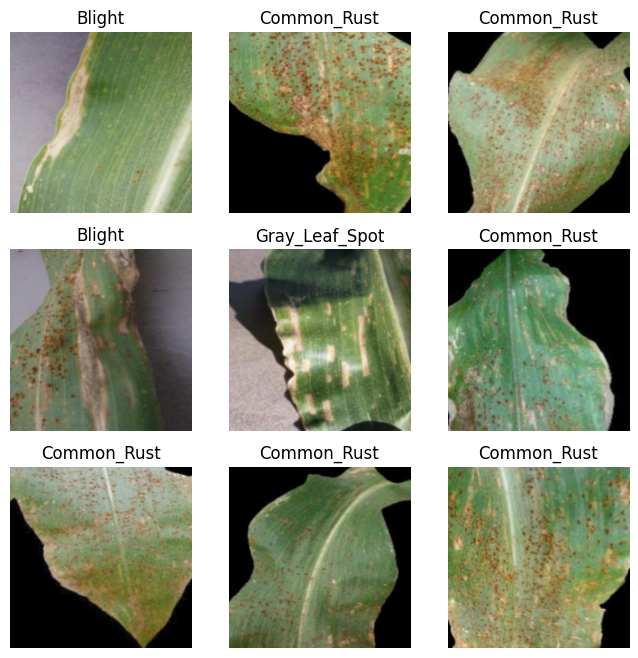

In [ ]:
 # prompt: convert the leaf_pod to a fastai data loader object
# promp: (it has errors so I say) fix this error (3 times, until no more error)
# Define the DataBlock for image classification
maize_leaf_block = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('pil_image_data'), # Get image from 'pil_image_data' column
    get_y=ColReader('disease_type'),   # label from 'disease_type' column
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms = items_tfms, # Corrected: Use the defined items_tfms which now includes ConvertImageToRGB
    batch_tfms=batch_tfms
)

# Create the DataLoaders object from the leaf_pd DataFrame using the DataBlock.
dls = maize_leaf_block.dataloaders(leaf_pd, bs=64, num_workers=0)

# Display a batch of images to verify the DataLoader is set up correctly.
dls.show_batch(max_n=9, figsize=(8, 8))

In [ ]:
# prompt: create fastai learner object from dls
# Create a fastai Lewarner object
# We will use a pre-trained ResNet34 model, which is common for image classifcation tasks.
# The metrics parameter will track accuracy during training.
learn = cnn_learner(dls, resnet34, metrics=accuracy)

# Display the Learner object to see its structure and parameters
print(learn)

/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 108MB/s]


<div></div>

SuggestedLRs(valley=0.0014454397605732083)
Suggested learning rate: 0.0014454397605732083


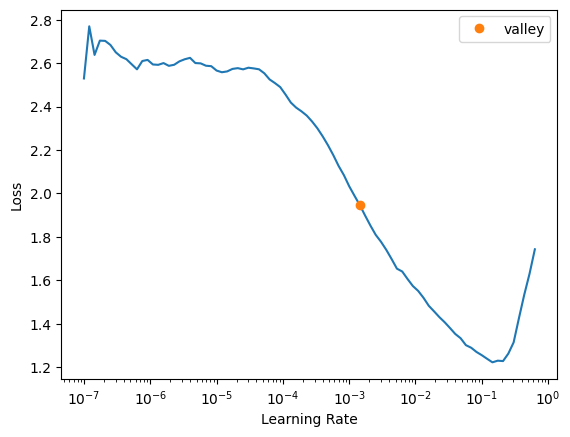

In [ ]:
# Find learning rate
lr_suggestion = learn.lr_find()

print(lr_suggestion)

# Use the valley suggestion
lr = lr_suggestion.valley

print(f"Suggested learning rate: {lr}")

<div></div>

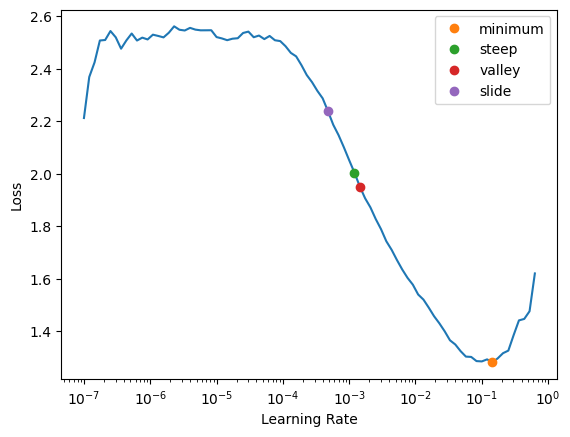

In [ ]:
lrates = learn.lr_find(suggest_funcs =(minimum, steep, valley, slide))

In [ ]:
lrates.slide

0.0004786300996784121

In [ ]:
learn.fine_tune(8, base_lr=lrates.slide)

epoch,train_loss,valid_loss,accuracy,time
0,1.283291,0.345498,0.867164,15:40


epoch,train_loss,valid_loss,accuracy,time
0,0.448803,0.286519,0.891045,23:24
1,0.375458,0.239332,0.916418,23:00
2,0.307771,0.216431,0.928358,23:19
3,0.240075,0.207930,0.937313,23:22
4,0.202285,0.194700,0.941791,22:54
5,0.170609,0.188265,0.943284,23:12
6,0.144110,0.189860,0.938806,23:09
7,0.133339,0.190399,0.938806,23:07


# Export and save leaner

export and save to deploy folder on github







In [ ]:
# prompt: export and save foxy.learner

fname = f"./leaf_disease_learner_{int(time.time())}.pkl"
learn.export(fname)
print(fname)

./leaf_disease_learner_1782835769.pkl


# Optional: Callback

In [ ]:
# prompt: print current unix timestamp

print(int(time.time()))

1782835933


In [ ]:
# Custom callback definition
class Foxy_cb(Callback):
  def before_fit(self):
    print("Foxy: Starting training...")
  #
  def after_fit(self):
    print("Foxy: Training complete!")
  #
  def after_epoch(self):
    print(f"Foxy: Time: {int(time.time())}")
    # Access the error_rate metric
    # error_rate_value = self.learn.recorder.metrics[-1][self.learn.recorder.metric_names.index('error_rate')]
    error_rate_name = self.learn.recorder.metrics[-1].name
    error_rate_value = self.learn.recorder.metrics[-1].value.item()
    print(f"Foxy: Error rate after epoch {self.learn.epoch}: Name: {error_rate_name}: Value: {error_rate_value}")
    print(f"Foxy: type learn: {type(self.learn)}")
    # check for exit
    if (error_rate_value <= 0.065):
      print("Foxy: Exiting training early...")
      # self.learn.cancel_training()
      # self.learn.cancel_train = True
    return

In [ ]:
# prompt: add in a call back function to the foxy.learner.fine_tune() method

learn.fine_tune(3, cbs=Foxy_cb())

Foxy: Starting training...


epoch,train_loss,valid_loss,accuracy,time
0,0.145201,0.214332,0.941791,16:30


Foxy: Time: 1782837271
Foxy: Error rate after epoch 0: Name: accuracy: Value: 0.9417910575866699
Foxy: type learn: <class 'fastai.learner.Learner'>
Foxy: Training complete!
Foxy: Starting training...


epoch,train_loss,valid_loss,accuracy,time
0,0.157121,0.222259,0.938806,23:19
1,0.163754,0.239528,0.931343,23:21


Foxy: Time: 1782838670
Foxy: Error rate after epoch 0: Name: accuracy: Value: 0.9388059973716736
Foxy: type learn: <class 'fastai.learner.Learner'>
Foxy: Time: 1782840071
Foxy: Error rate after epoch 1: Name: accuracy: Value: 0.9313432574272156
Foxy: type learn: <class 'fastai.learner.Learner'>


epoch,train_loss,valid_loss,accuracy,time
0,0.157121,0.222259,0.938806,23:19
1,0.163754,0.239528,0.931343,23:21
2,0.119269,0.182800,0.949254,22:48


Foxy: Time: 1782841439
Foxy: Error rate after epoch 2: Name: accuracy: Value: 0.9492537379264832
Foxy: type learn: <class 'fastai.learner.Learner'>
Foxy: Training complete!


In [ ]:
# prompt: how to create p1 as a TensorBase value 0.9

p1 = TensorBase(0.9)


In [ ]:
type(p1)

fastai.torch_core.TensorBase

In [ ]:
# prompt: convert p1 to float

p2 = p1.item()
print(p2, type(p2))

0.8999999761581421 <class 'float'>


In [ ]:
import fastai
from fastai.vision.all import *
help(fastai.learner.AvgMetric)

Help on class AvgMetric in module fastai.learner:

class AvgMetric(Metric)
 |  AvgMetric(func)
 |
 |  Average the values of `func` taking into account potential different batch sizes
 |
 |  Method resolution order:
 |      AvgMetric
 |      Metric
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, func)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  accumulate(self, learn)
 |      Use `learn` to update the state with new results
 |
 |  reset(self)
 |      Reset inner state to prepare for new computation
 |
 |  ----------------------------------------------------------------------
 |  Readonly properties defined here:
 |
 |  name
 |      Name of the `Metric`, camel-cased and with Metric removed
 |
 |  value
 |      The value of the metric
 |
 |  ----------------------------------------------------------------------
 |  Data and other attributes defined here:
 |
 |  __slotnames__ = []
 |
 |  ------------------------------------------

In [ ]:
import fastai
help(fastai.learner.Learner)

Help on class Learner in module fastai.learner:

class Learner(fastcore.basics.GetAttr)
 |  Learner(dls: 'DataLoaders', model: 'Callable', loss_func: 'Callable | None' = None, opt_func: 'Optimizer | OptimWrapper' = <function Adam at 0x7d241a7a3880>, lr: 'float | slice' = 0.001, splitter: 'Callable' = <function trainable_params at 0x7d2422188680>, cbs: 'Callback | MutableSequence | None' = None, metrics: 'Callable | MutableSequence | None' = None, path: 'str | Path | None' = None, model_dir: 'str | Path' = 'models', wd: 'float | int | None' = None, wd_bn_bias: 'bool' = False, train_bn: 'bool' = True, moms: 'tuple' = (0.95, 0.85, 0.95), default_cbs: 'bool' = True)
 |
 |  Group together a `model`, some `dls` and a `loss_func` to handle training
 |
 |  Method resolution order:
 |      Learner
 |      fastcore.basics.GetAttr
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __call__(self, event_name)
 |      Call `event_name` for all `Callback`s in `self.cbs`
 |
 |  __enter__(self

## Smoke test learner (CNN)

In [ ]:
# hand code (not using GenAI)

learn.summary()

<div></div>

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      

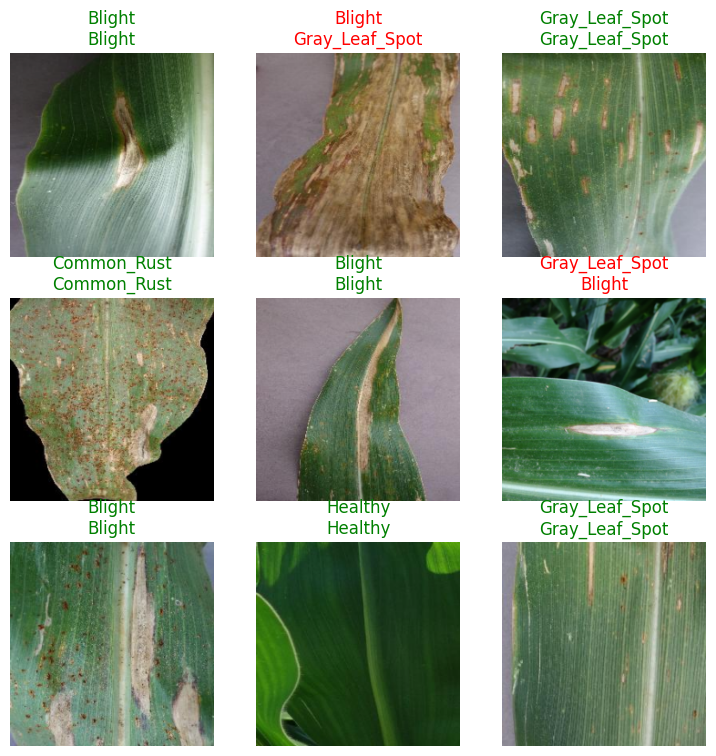

In [ ]:
# hand code (not using GenAI)

learn.show_results()

In [ ]:
 # learner.recorder.plot_loss(skip_start=1, with_valid=True, suggestion=True)

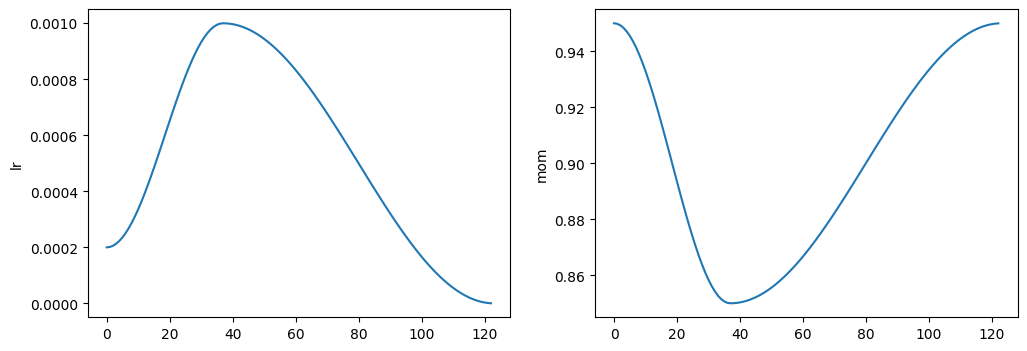

In [ ]:
# hand code (not using GenAI)

learn.recorder.plot_sched()

In [ ]:
learn.show_training_loop()

Start Fit
   - before_fit     : [TrainEvalCallback, Recorder, ProgressCallback]
  Start Epoch Loop
     - before_epoch   : [Recorder, ProgressCallback]
    Start Train
       - before_train   : [TrainEvalCallback, Recorder, ProgressCallback]
      Start Batch Loop
         - before_batch   : [CastToTensor]
         - after_pred     : []
         - after_loss     : []
         - before_backward: []
         - before_step    : []
         - after_step     : []
         - after_cancel_batch: []
         - after_batch    : [TrainEvalCallback, Recorder, ProgressCallback]
      End Batch Loop
    End Train
     - after_cancel_train: [Recorder]
     - after_train    : [Recorder, ProgressCallback]
    Start Valid
       - before_validate: [TrainEvalCallback, Recorder, ProgressCallback]
      Start Batch Loop
         - **CBs same as train batch**: []
      End Batch Loop
    End Valid
     - after_cancel_validate: [Recorder]
     - after_validate : [Recorder, ProgressCallback]
  End Epoch Loop

In [ ]:
 # hand code (not using GenAI)

smoke_learner = fastai.interpret.Interpretation.from_learner(learn)

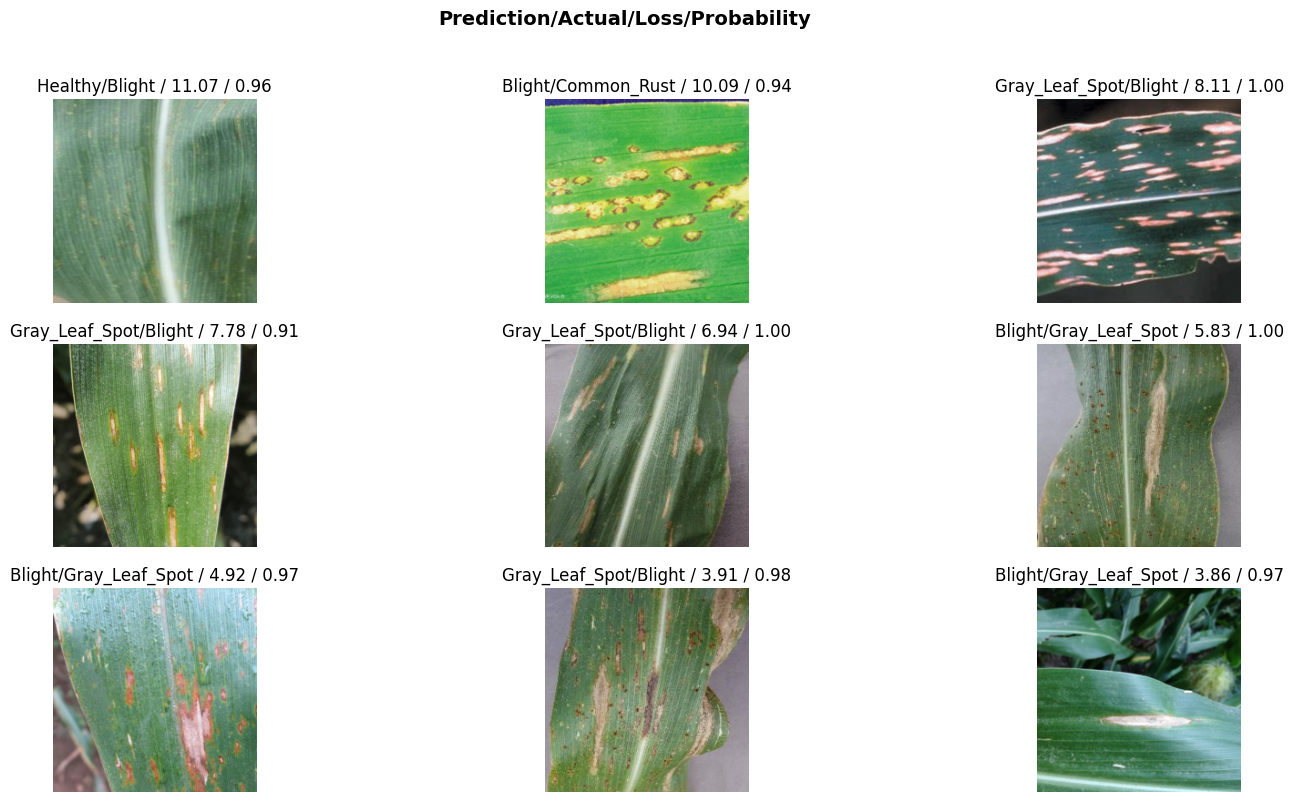

In [ ]:
# hand code (not using GenAI)

smoke_learner.plot_top_losses(9, figsize=(18,9))

In [ ]:
# hand code (not using GenAI)

smoke_learner.top_losses(21)

(TensorBase([11.0680, 10.0859,  8.1123,  7.7841,  6.9429,  5.8337,  4.9212,
              3.9108,  3.8559,  3.6269,  3.5210,  3.0849,  2.7639,  2.6890,
              2.6228,  2.5393,  2.2833,  2.1489,  1.9580,  1.8505,  1.8175]),
 TensorBase([252, 131, 182, 599, 400, 519, 453, 163, 230,   0, 240, 288, 261,
             511, 424, 413, 621, 544, 318, 321, 499]))

In [ ]:
# hand code (not using GenAI)

from fastai.interpret import ClassificationInterpretation
smoke_learner = ClassificationInterpretation.from_learner(learn)
# smoke_learner = fastai.interpret.Interpretation.from_learner(foxy.learner)

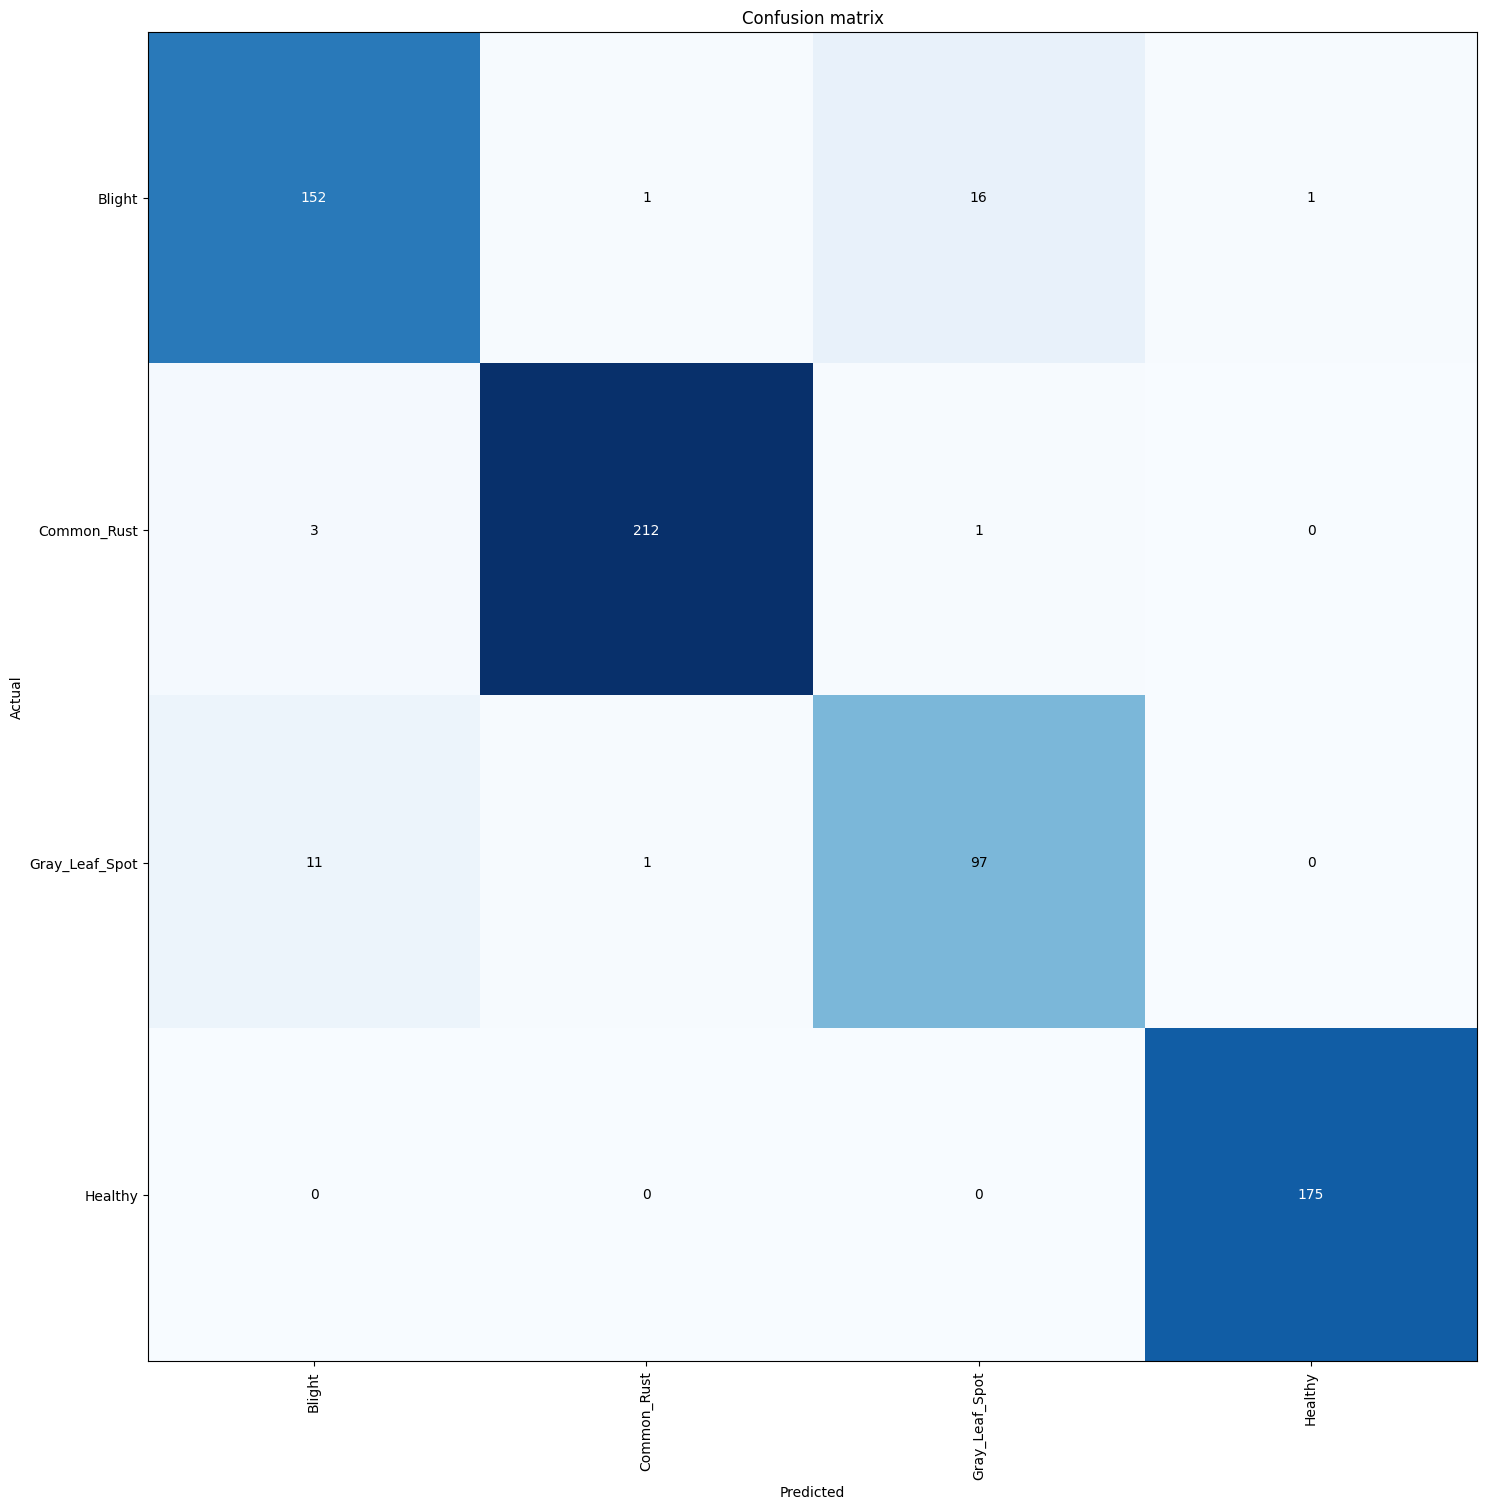

In [ ]:
# hand code (not using GenAI)

smoke_learner.plot_confusion_matrix(figsize=(15,15))

In [ ]:
# hand code (not using GenAI)

smoke_learner.print_classification_report()

                precision    recall  f1-score   support

        Blight       0.92      0.89      0.90       170
   Common_Rust       0.99      0.98      0.99       216
Gray_Leaf_Spot       0.85      0.89      0.87       109
       Healthy       0.99      1.00      1.00       175

      accuracy                           0.95       670
     macro avg       0.94      0.94      0.94       670
  weighted avg       0.95      0.95      0.95       670



# Load CNN
load the saved leaner in pickle (*.pkl) format

In [ ]:
# # smoke test it
# !ls -la foxy_cnn_image_classification

In [ ]:
# !ls -la foxy_cnn_image_classification/deploy
!ls -la

total 436888
drwxr-xr-x 1 root root      4096 Jun 30 16:09 .
drwxr-xr-x 1 root root      4096 Jun 30 10:39 ..
drwxr-xr-x 4 root root      4096 Jun  4 13:32 .config
-rw-r--r-- 1 root root  87560047 Jun 30 16:09 leaf_disease_learner_1782835769.pkl
-rw-r--r-- 1 root root 359791307 Jun 30 11:06 maize_leaf_data.csv
drwxr-xr-x 2 root root      4096 Jun 30 12:39 models
drwxr-xr-x 1 root root      4096 Jun  4 13:32 sample_data


In [ ]:
maize_leaf_engine = "./leaf_disease_learner_1782835769.pkl"

In [ ]:
# if jump directly here then we need to install fastai

!pip install fastai
import fastai

In [ ]:
# prompt: check fastai version

import fastai
print(fastai.__version__)

2.8.7


In [ ]:
!ls -la

total 436888
drwxr-xr-x 1 root root      4096 Jun 30 16:09 .
drwxr-xr-x 1 root root      4096 Jun 30 10:39 ..
drwxr-xr-x 4 root root      4096 Jun  4 13:32 .config
-rw-r--r-- 1 root root  87560047 Jun 30 16:09 leaf_disease_learner_1782835769.pkl
-rw-r--r-- 1 root root 359791307 Jun 30 11:06 maize_leaf_data.csv
drwxr-xr-x 2 root root      4096 Jun 30 12:39 models
drwxr-xr-x 1 root root      4096 Jun  4 13:32 sample_data


In [ ]:
!pwd

/content


Copyright (c) 2026 Victor Jimmy
All rights reserved.

This work, including all code, models, data, and documentation, is the
exclusive property of the copyright holder. No part of this work may be
copied, reproduced, modified, distributed, or used in any form without
explicit written permission from the copyright holder.
